# Parte C – Stabilità del portafoglio di tangenza e ruolo della dimensione del problema

L'obiettivo di questa parte è analizzare la **stabilità dei portafogli ottimali** rispetto all'errore di stima e studiare il ruolo del **rapporto N/T** (numero di asset su numero di osservazioni).

- **Punto 1** → Fissare T = 120 mesi (l'intero campione usato nelle Parti A e B).
- **Punto 2** → Costruire due sottoinsiemi di asset: N=5 (primi 5 titoli) e N=10 (tutti).
- **Punto 3** → Bootstrap i.i.d. con B=500 campioni di T=120 mesi: stimare mu, Sigma e calcolare il portafoglio di tangenza con la formula analitica.
- **Punto 4** → Distribuzione dei pesi e dello Sharpe Ratio per N=5 e N=10.
- **Punto 5** → Confronto e commento sull'effetto di N/T sulla stabilità.

Ogni blocco ha la stessa struttura dei notebook A e B: cella markdown con teoria e formule, seguita dal codice commentato.

---
## Blocco 0 – Import e configurazione

In [14]:
# =============================================================================
# IMPORT
# Stesse librerie delle Parti A e B, più scipy.linalg per la risoluzione
# stabile del sistema Sigma * z = exc (più robusta di np.linalg.inv)
# =============================================================================
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import linalg

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# =============================================================================
# CONFIGURAZIONE (identica alle Parti A e B per coerenza)
# =============================================================================

TICKERS = {
    'Tech':       ['AAPL', 'MSFT', 'NVDA'],
    'Healthcare': ['JNJ',  'PFE',  'MRK'],
    'Energy':     ['XOM',  'CVX',  'BP'],
    'Index':      ['^GSPC'],
}
ALL_TICKERS = [t for group in TICKERS.values() for t in group]

rf_annual = 0.02        # tasso risk-free annuo (proxy BOT 3 mesi 2015-2025)
ann       = 12          # fattore di annualizzazione
rf        = rf_annual / ann   # tasso mensile: 0.1667%

START = '2015-01-01'
END   = '2025-01-01'

# Parametri bootstrap
T_BOOT = 120   # lunghezza di ogni campione bootstrap (uguale a T storico)
B      = 500   # numero di campioni bootstrap

np.random.seed(42)   # per riproducibilità dei risultati

print(f'Parametri: rf={rf_annual*100:.1f}% annuo | T_boot={T_BOOT} mesi | B={B} campioni')
print(f'Periodo storico: {START} → {END}')

Parametri: rf=2.0% annuo | T_boot=120 mesi | B=500 campioni
Periodo storico: 2015-01-01 → 2025-01-01


---
## Blocco 1 – Download dati e rendimenti

Notebook autonomo: scarica i dati da zero, indipendentemente dalle Parti A e B.

In [15]:
# Download prezzi mensili adjusted (total return, dividendi inclusi)
# Stessa procedura delle Parti A e B per coerenza dei dati
raw    = yf.download(ALL_TICKERS, start=START, end=END, auto_adjust=True, progress=True)
prices = raw['Close'].resample('ME').last()
prices.columns = [c if c != '^GSPC' else 'SP500' for c in prices.columns]
prices.dropna(how='all', inplace=True)

# Rendimenti logaritmici mensili: r_t = ln(P_t / P_{t-1})
returns = np.log(prices / prices.shift(1)).dropna()

ALL_COLS = list(returns.columns)   # ordine alfabetico (come restituisce yfinance)
T_tot    = len(returns)

print(f'Osservazioni: {T_tot} mesi  ({returns.index[0].date()} → {returns.index[-1].date()})')
print(f'Titoli ({len(ALL_COLS)}): {ALL_COLS}')
returns.tail(3)

[*********************100%***********************]  10 of 10 completed

Osservazioni: 119 mesi  (2015-02-28 → 2024-12-31)
Titoli (10): ['AAPL', 'BP', 'CVX', 'JNJ', 'MRK', 'MSFT', 'NVDA', 'PFE', 'XOM', 'SP500']


,AAPL,BP,CVX,JNJ,MRK,MSFT,NVDA,PFE,XOM,SP500
Date,,,,,,,,,,
2024-10-31,-0.030902,-0.066856,0.010470,-0.013668,-0.104226,-0.057268,0.089123,-0.022363,-0.003761,-0.009946
2024-11-30,0.050414,0.014269,0.094576,-0.022817,-0.006668,0.043244,0.040521,-0.061308,0.018237,0.055720
2024-12-31,0.053688,0.008493,-0.111534,-0.069380,-0.013508,-0.004639,-0.028993,0.012135,-0.092204,-0.025308


---
## Blocco 2 – Setup: sottoinsiemi N=5 e N=10 (Punti 1–2)

**Punto 1:** T = 120 mesi (intero campione storico disponibile).

**Punto 2:** Due sottoinsiemi di asset:
- **Caso 1** (N=5): stessi 5 titoli selezionati nella Parte A per la frontiera efficiente (NVDA, MSFT, JNJ, MRK, XOM)
- **Caso 2** (N=10): tutti i 10 titoli/indici

**Nota importante:** non si modifica la scelta dei titoli tra un caso e l'altro — l'obiettivo è variare solo N per studiare l'effetto del rapporto N/T.

| Caso | N | N/T |
|------|---|-----|
| 1    | 5 | 5/120 ≈ 0.042 |
| 2    | 10 | 10/120 ≈ 0.083 |


In [16]:
# =============================================================================
# Definizione dei sottoinsiemi
# Opzione A: stessi 5 titoli scelti nella Parte A per la frontiera efficiente
# (NVDA, MSFT, JNJ, MRK, XOM) → massima coerenza con il resto del progetto.
# =============================================================================
SELECTED_5 = ['NVDA', 'MSFT', 'JNJ', 'MRK', 'XOM']   # selezione della Parte A
TICKERS_5  = SELECTED_5
TICKERS_10 = ALL_COLS        # N=10: tutti
assert set(TICKERS_5).issubset(set(TICKERS_10)), \
    f"Errore: {TICKERS_5} non è sottoinsieme di {TICKERS_10}"

print(f'Caso 1 – N=5  (stessi 5 della Parte A): {TICKERS_5}')
print(f'Caso 2 – N=10 (tutti):                   {TICKERS_10}')
print()
print(f'T storico utilizzato:  T = {T_tot} mesi')
print(f'T per campione boot.:  T = {T_BOOT} mesi')
print(f'Campioni bootstrap:    B = {B}')
print()
print(f'Rapporto N/T – Caso 1: {5}/{T_BOOT} = {5/T_BOOT:.4f}')
print(f'Rapporto N/T – Caso 2: {10}/{T_BOOT} = {10/T_BOOT:.4f}')


Caso 1 – N=5  (stessi 5 della Parte A): ['NVDA', 'MSFT', 'JNJ', 'MRK', 'XOM']
Caso 2 – N=10 (tutti):                   ['AAPL', 'BP', 'CVX', 'JNJ', 'MRK', 'MSFT', 'NVDA', 'PFE', 'XOM', 'SP500']

T storico utilizzato:  T = 119 mesi
T per campione boot.:  T = 120 mesi
Campioni bootstrap:    B = 500

Rapporto N/T – Caso 1: 5/120 = 0.0417
Rapporto N/T – Caso 2: 10/120 = 0.0833


---
## Blocco 3 – Funzione portafoglio di tangenza e bootstrap (Punto 3)

### Portafoglio di tangenza (formula analitica)

Il portafoglio di tangenza massimizza lo Sharpe Ratio ed è la soluzione del problema:

$$\max_{\mathbf{w}} \frac{\mathbf{w}'\boldsymbol{\mu} - r_f}{\sqrt{\mathbf{w}'\boldsymbol{\Sigma}\mathbf{w}}} \quad \text{s.t.} \quad \mathbf{1}'\mathbf{w} = 1$$

La soluzione analitica (dalla condizione del primo ordine, eq. 23 delle slides) è:

$$\mathbf{z} = \boldsymbol{\Sigma}^{-1}(\boldsymbol{\mu} - r_f\,\mathbf{1}), \qquad \mathbf{w}_{\text{tan}} = \frac{\mathbf{z}}{\mathbf{1}'\mathbf{z}}$$

Lo **Sharpe Ratio annualizzato** del portafoglio di tangenza:

$$\text{SR}_{\text{tan}} = \frac{\mu_{\text{tan}} - r_f}{\sigma_{\text{tan}}} \cdot \sqrt{12}$$

### Bootstrap i.i.d.

Per ogni campione $b = 1, \ldots, B$:
1. Estrai T=120 righe con reinserimento da $\{r_{1}, \ldots, r_{T_{\text{tot}}}\}$
2. Stima $\hat{\boldsymbol{\mu}}^{(b)}$ e $\hat{\boldsymbol{\Sigma}}^{(b)}$ sul campione
3. Calcola $\mathbf{w}_{\text{tan}}^{(b)}$ e $\text{SR}^{(b)}$

In [17]:
# =============================================================================
# FUNZIONE: portafoglio di tangenza (formula analitica)
# =============================================================================
def tangency_portfolio(mu, Sigma, rf):
    """
    Calcola il portafoglio di tangenza con la formula analitica.
    Short selling ammesso (nessun vincolo di positività sui pesi).

    Formula:
        z     = Sigma^{-1} (mu - rf*iota)   # risolto con linalg.solve
        w_tan = z / (iota' z)               # normalizzazione: sum(w) = 1

    Sharpe Ratio annualizzato: SR = (mu_p - rf) / sigma_p * sqrt(12)

    Ritorna (w, SR, ok) dove ok=False se il denominatore è ≤ 0
    (tutti gli excess return negativi → nessun portafoglio con SR>0 esiste)
    """
    N    = len(mu)
    iota = np.ones(N)
    exc  = mu - rf * iota              # excess return mensile

    # linalg.solve(Sigma, exc) più stabile numericamente di inv(Sigma) @ exc
    try:
        z = linalg.solve(Sigma, exc, assume_a='pos')
    except linalg.LinAlgError:
        return np.full(N, np.nan), np.nan, False

    denom = float(iota @ z)   # = iota' Sigma^{-1} (mu - rf*iota)

    if denom <= 0:
        # Tutti gli asset con rendimento atteso < rf: tangenza non esiste
        return np.full(N, np.nan), np.nan, False

    w     = z / denom                           # pesi: iota'w = 1
    mu_p  = float(w @ mu)                       # rendimento mensile portafoglio
    sig_p = float(np.sqrt(w @ Sigma @ w))       # std dev mensile portafoglio
    SR    = (mu_p - rf) / sig_p * np.sqrt(ann)  # SR annualizzato

    return w, SR, True


# =============================================================================
# FUNZIONE: bootstrap i.i.d.
# =============================================================================
def bootstrap_tangency(returns_df, rf, T_boot, B):
    """
    Esegue il bootstrap i.i.d. dei rendimenti e stima il portafoglio di
    tangenza per ognuno dei B campioni.

    Ritorna
    -------
    weights_boot : (B, N) array – pesi tangenza per ogni campione
    sharpes_boot : (B,)   array – SR annualizzato per ogni campione
    n_valid      : int   – campioni con denominatore > 0
    """
    T_tot = len(returns_df)
    N     = returns_df.shape[1]
    ret   = returns_df.values     # ndarray (T_tot, N) per velocità

    weights_boot = np.full((B, N), np.nan)
    sharpes_boot = np.full(B, np.nan)

    for b in range(B):
        # Campionamento con reinserimento: T_boot indici in {0, ..., T_tot-1}
        idx    = np.random.randint(0, T_tot, size=T_boot)
        sample = ret[idx, :]       # (T_boot, N)

        # Stima mu e Sigma sul campione bootstrap (ddof=1 = stimatore non distorto)
        mu_b    = sample.mean(axis=0)
        Sigma_b = np.cov(sample, rowvar=False, ddof=1)

        w, SR, ok = tangency_portfolio(mu_b, Sigma_b, rf)
        if ok:
            weights_boot[b, :] = w
            sharpes_boot[b]    = SR

    n_valid = int(np.sum(~np.isnan(sharpes_boot)))
    return weights_boot, sharpes_boot, n_valid


print('Funzioni tangency_portfolio e bootstrap_tangency definite.')

Funzioni tangency_portfolio e bootstrap_tangency definite.


In [18]:
# =============================================================================
# BOOTSTRAP N=5 – esecuzione
# =============================================================================
print(f'Bootstrap N=5 ({B} campioni × {T_BOOT} mesi)...')
ws5, srs5, n_valid5 = bootstrap_tangency(returns[TICKERS_5], rf, T_BOOT, B)
print(f'Campioni validi: {n_valid5}/{B}')

# Portafoglio di tangenza storico N=5 (benchmark sull'intero campione)
mu5_stor  = returns[TICKERS_5].mean().values
Sig5_stor = returns[TICKERS_5].cov().values
w5_stor, sr5_stor, _ = tangency_portfolio(mu5_stor, Sig5_stor, rf)
print(f'SR storico N=5 (intero campione): {sr5_stor:.4f}')

# =============================================================================
# TABELLA: media e std dei pesi (richiesta dal Punto 4)
# =============================================================================
means5 = np.nanmean(ws5, axis=0)
stds5  = np.nanstd(ws5,  axis=0)

tab5 = pd.DataFrame({
    'Peso storico':    w5_stor.round(4),
    'Media bootstrap': means5.round(4),
    'Std bootstrap':   stds5.round(4),
    'CV (std/|media|)': (stds5 / np.abs(means5)).round(3),
}, index=TICKERS_5)

print(f'\nDistribuzione pesi portafoglio di tangenza – N=5 (N/T={5/T_BOOT:.3f})')
display(tab5)
print(f'\nSharpe Ratio bootstrap – media: {np.nanmean(srs5):.4f}  |  std: {np.nanstd(srs5):.4f}')

Bootstrap N=5 (500 campioni × 120 mesi)...
Campioni validi: 491/500
SR storico N=5 (intero campione): 1.3278

Distribuzione pesi portafoglio di tangenza – N=5 (N/T=0.042)


,Peso storico,Media bootstrap,Std bootstrap,CV (std/|media|)
NVDA,0.3960,0.5770,0.8148,1.412
MSFT,0.5395,0.6968,1.5855,2.276
JNJ,-0.0695,-0.4049,1.9749,4.878
MRK,0.2544,0.2616,1.7191,6.573
XOM,-0.1204,-0.1304,0.9523,7.301



Sharpe Ratio bootstrap – media: 1.5065  |  std: 0.3336


/var/folders/j6/f3l_gtn56y7b6lcqwtnv8dym0000gn/T/ipykernel_20077/818860107.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([valid5[:, i] for i in range(5)],


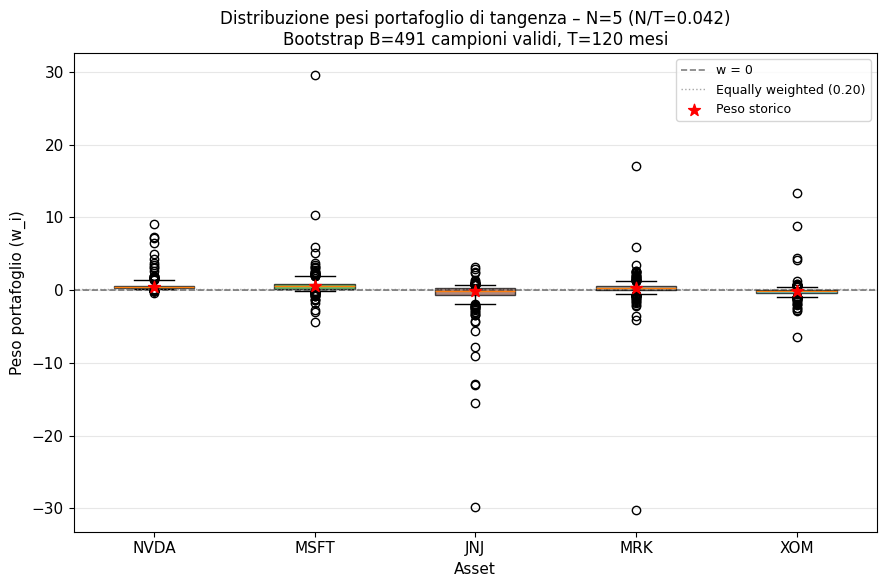

Salvato: bootstrap_weights_N5_C4.png


In [19]:
# =============================================================================
# GRAFICO 1 – Boxplot dei pesi N=5
# =============================================================================
valid5 = ws5[~np.isnan(ws5[:, 0]), :]   # rimuovi righe NaN

fig, ax = plt.subplots(figsize=(9, 6))

# Boxplot con whiskers al 5° e 95° percentile (robusto agli outlier estremi)
bp = ax.boxplot([valid5[:, i] for i in range(5)],
                labels=TICKERS_5, patch_artist=True,
                whis=[5, 95], showfliers=True)

colors = plt.cm.tab10(np.linspace(0, 1, 5))
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c); patch.set_alpha(0.7)

ax.axhline(0,   color='black', lw=1.2, ls='--', alpha=0.5, label='w = 0')
ax.axhline(1/5, color='grey',  lw=1.0, ls=':',  alpha=0.7, label='Equally weighted (0.20)')

# Segna i pesi storici come asterischi
for i, w in enumerate(w5_stor):
    ax.scatter(i+1, w, color='red', s=80, marker='*', zorder=6,
               label='Peso storico' if i == 0 else '')

ax.set_title(f'Distribuzione pesi portafoglio di tangenza – N=5 (N/T={5/T_BOOT:.3f})\n'
             f'Bootstrap B={n_valid5} campioni validi, T={T_BOOT} mesi', fontsize=12)
ax.set_ylabel('Peso portafoglio (w_i)')
ax.set_xlabel('Asset')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='y')

fig.tight_layout()
fig.savefig('bootstrap_weights_N5_C4.png', dpi=150)
plt.show()
print('Salvato: bootstrap_weights_N5_C4.png')

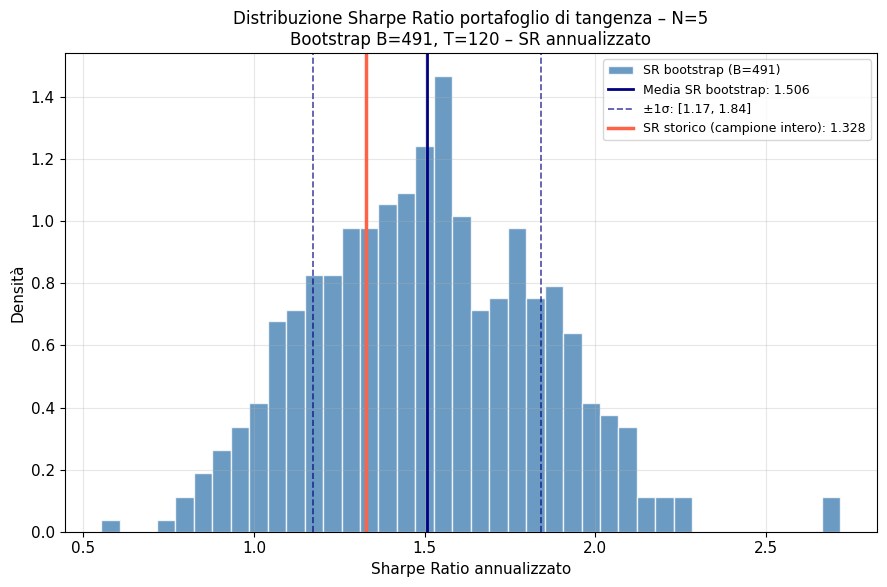

Salvato: bootstrap_sharpe_N5_C4.png


In [20]:
# =============================================================================
# GRAFICO 2 – Istogramma Sharpe Ratio N=5
# =============================================================================
sr5_valid = srs5[~np.isnan(srs5)]
mu_sr5  = np.mean(sr5_valid)
std_sr5 = np.std(sr5_valid)

fig, ax = plt.subplots(figsize=(9, 6))

ax.hist(sr5_valid, bins=40, color='steelblue', edgecolor='white',
        alpha=0.8, density=True, label=f'SR bootstrap (B={len(sr5_valid)})')

# Media e ±1 std della distribuzione bootstrap
ax.axvline(mu_sr5,          color='navy', lw=2.0, ls='-',
           label=f'Media SR bootstrap: {mu_sr5:.3f}')
ax.axvline(mu_sr5 + std_sr5, color='navy', lw=1.2, ls='--', alpha=0.7,
           label=f'±1σ: [{mu_sr5-std_sr5:.2f}, {mu_sr5+std_sr5:.2f}]')
ax.axvline(mu_sr5 - std_sr5, color='navy', lw=1.2, ls='--', alpha=0.7)

# SR storico sull'intero campione (benchmark)
ax.axvline(sr5_stor, color='tomato', lw=2.5, ls='-',
           label=f'SR storico (campione intero): {sr5_stor:.3f}')

ax.set_title(f'Distribuzione Sharpe Ratio portafoglio di tangenza – N=5\n'
             f'Bootstrap B={len(sr5_valid)}, T={T_BOOT} – SR annualizzato', fontsize=12)
ax.set_xlabel('Sharpe Ratio annualizzato'); ax.set_ylabel('Densità')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig('bootstrap_sharpe_N5_C4.png', dpi=150)
plt.show()
print('Salvato: bootstrap_sharpe_N5_C4.png')

---
## Blocco 5 – Bootstrap N=10 (Punto 3–4)

Stesso procedimento per **tutti i 10 titoli** (N=10, N/T ≈ 0.083).

Con N=10 e T=120:
- Si stimano $N(N+1)/2 = 55$ parametri della matrice $\Sigma$ con soli 120 osservazioni
- L'**errore di stima** è maggiore rispetto al caso N=5
- L'ottimizzatore tende ad amplificare gli errori → pesi più estremi e variabili

In [21]:
# =============================================================================
# BOOTSTRAP N=10 – esecuzione
# =============================================================================
print(f'Bootstrap N=10 ({B} campioni × {T_BOOT} mesi)...')
ws10, srs10, n_valid10 = bootstrap_tangency(returns[TICKERS_10], rf, T_BOOT, B)
print(f'Campioni validi: {n_valid10}/{B}')

# Portafoglio di tangenza storico N=10 (benchmark)
mu10_stor  = returns[TICKERS_10].mean().values
Sig10_stor = returns[TICKERS_10].cov().values
w10_stor, sr10_stor, _ = tangency_portfolio(mu10_stor, Sig10_stor, rf)
print(f'SR storico N=10 (intero campione): {sr10_stor:.4f}')

# =============================================================================
# TABELLA: media e std dei pesi (Punto 4)
# =============================================================================
means10 = np.nanmean(ws10, axis=0)
stds10  = np.nanstd(ws10,  axis=0)

tab10 = pd.DataFrame({
    'Peso storico':    w10_stor.round(4),
    'Media bootstrap': means10.round(4),
    'Std bootstrap':   stds10.round(4),
    'CV (std/|media|)': (stds10 / np.abs(means10)).round(3),
}, index=TICKERS_10)

print(f'\nDistribuzione pesi portafoglio di tangenza – N=10 (N/T={10/T_BOOT:.3f})')
display(tab10)
print(f'\nSharpe Ratio bootstrap – media: {np.nanmean(srs10):.4f}  |  std: {np.nanstd(srs10):.4f}')

Bootstrap N=10 (500 campioni × 120 mesi)...
Campioni validi: 400/500
SR storico N=10 (intero campione): 1.5255

Distribuzione pesi portafoglio di tangenza – N=10 (N/T=0.083)


,Peso storico,Media bootstrap,Std bootstrap,CV (std/|media|)
AAPL,0.4325,1.3336,7.8908,5.917
BP,-0.5511,-1.5168,8.1690,5.386
CVX,0.6329,2.6787,28.2884,10.560
JNJ,0.8391,1.3419,7.1098,5.298
MRK,0.6331,1.3988,10.5335,7.530
MSFT,1.8436,4.0110,18.8344,4.696
NVDA,1.0617,2.4336,8.9503,3.678
PFE,-0.3362,-1.1476,7.4943,6.531
XOM,0.3194,-0.6516,21.4064,32.851
SP500,-3.8749,-8.8817,37.7037,4.245



Sharpe Ratio bootstrap – media: 1.9105  |  std: 0.3497


/var/folders/j6/f3l_gtn56y7b6lcqwtnv8dym0000gn/T/ipykernel_20077/590196929.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([valid10[:, i] for i in range(10)],


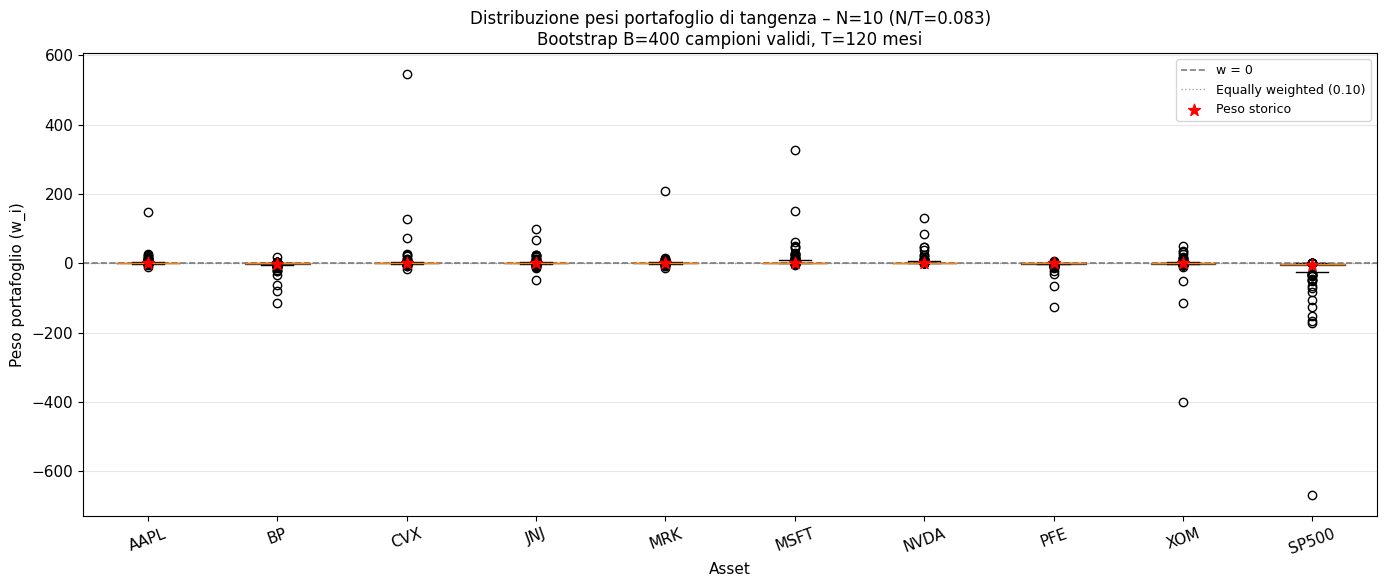

Salvato: bootstrap_weights_N10_C4.png


In [22]:
# =============================================================================
# GRAFICO 3 – Boxplot dei pesi N=10
# =============================================================================
valid10 = ws10[~np.isnan(ws10[:, 0]), :]

fig, ax = plt.subplots(figsize=(14, 6))

bp = ax.boxplot([valid10[:, i] for i in range(10)],
                labels=TICKERS_10, patch_artist=True,
                whis=[5, 95], showfliers=True)

colors = plt.cm.tab10(np.linspace(0, 1, 10))
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c); patch.set_alpha(0.7)

ax.axhline(0,    color='black', lw=1.2, ls='--', alpha=0.5, label='w = 0')
ax.axhline(1/10, color='grey',  lw=1.0, ls=':',  alpha=0.7, label='Equally weighted (0.10)')

for i, w in enumerate(w10_stor):
    ax.scatter(i+1, w, color='red', s=80, marker='*', zorder=6,
               label='Peso storico' if i == 0 else '')

ax.set_title(f'Distribuzione pesi portafoglio di tangenza – N=10 (N/T={10/T_BOOT:.3f})\n'
             f'Bootstrap B={n_valid10} campioni validi, T={T_BOOT} mesi', fontsize=12)
ax.set_ylabel('Peso portafoglio (w_i)')
ax.set_xlabel('Asset')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='y')
ax.tick_params(axis='x', rotation=20)

fig.tight_layout()
fig.savefig('bootstrap_weights_N10_C4.png', dpi=150)
plt.show()
print('Salvato: bootstrap_weights_N10_C4.png')

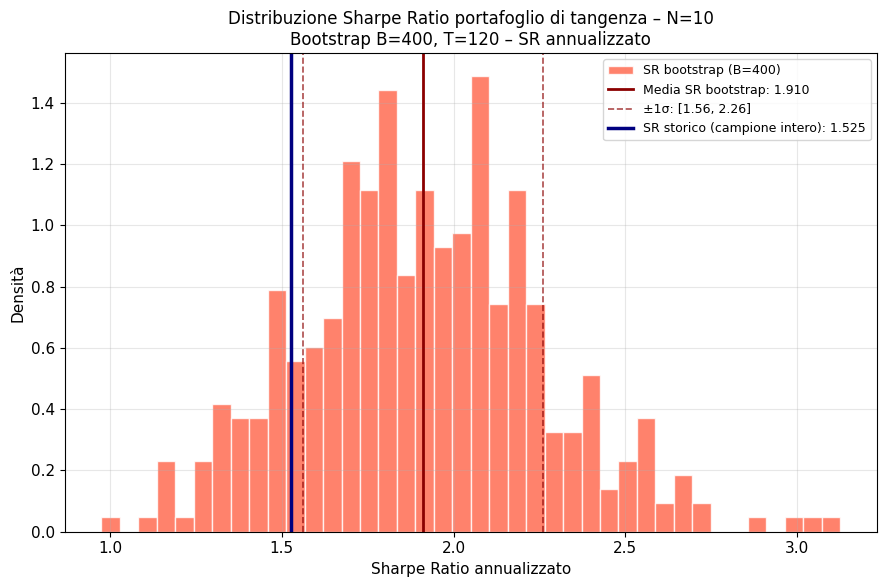

Salvato: bootstrap_sharpe_N10_C4.png


In [23]:
# =============================================================================
# GRAFICO 4 – Istogramma Sharpe Ratio N=10
# =============================================================================
sr10_valid = srs10[~np.isnan(srs10)]
mu_sr10  = np.mean(sr10_valid)
std_sr10 = np.std(sr10_valid)

fig, ax = plt.subplots(figsize=(9, 6))

ax.hist(sr10_valid, bins=40, color='tomato', edgecolor='white',
        alpha=0.8, density=True, label=f'SR bootstrap (B={len(sr10_valid)})')

ax.axvline(mu_sr10,           color='darkred', lw=2.0, ls='-',
           label=f'Media SR bootstrap: {mu_sr10:.3f}')
ax.axvline(mu_sr10 + std_sr10, color='darkred', lw=1.2, ls='--', alpha=0.7,
           label=f'±1σ: [{mu_sr10-std_sr10:.2f}, {mu_sr10+std_sr10:.2f}]')
ax.axvline(mu_sr10 - std_sr10, color='darkred', lw=1.2, ls='--', alpha=0.7)

ax.axvline(sr10_stor, color='navy', lw=2.5, ls='-',
           label=f'SR storico (campione intero): {sr10_stor:.3f}')

ax.set_title(f'Distribuzione Sharpe Ratio portafoglio di tangenza – N=10\n'
             f'Bootstrap B={len(sr10_valid)}, T={T_BOOT} – SR annualizzato', fontsize=12)
ax.set_xlabel('Sharpe Ratio annualizzato'); ax.set_ylabel('Densità')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig('bootstrap_sharpe_N10_C4.png', dpi=150)
plt.show()
print('Salvato: bootstrap_sharpe_N10_C4.png')

---
## Blocco 6 – Confronto N=5 vs N=10 (Punto 5)

### Effetto del rapporto N/T sulla stabilità

Con T fisso, all'aumentare di N:
1. **Più parametri da stimare**: $\Sigma$ ha $N(N+1)/2$ elementi → N=5: 15 parametri, N=10: 55 parametri
2. **Errore di stima maggiore**: le stime di $\hat{\mu}$ e $\hat{\Sigma}$ diventano meno precise
3. **"Error maximization"**: l'ottimizzatore di portafoglio amplifica gli errori di stima
4. **Pesi più instabili**: la distribuzione bootstrap dei pesi si allarga
5. **SR più disperso**: maggiore incertezza sulla performance realizzata

La soglia critica è $N \approx T$: quando $N = T$ la matrice $\Sigma$ è singolare (rango deficiente) e non invertibile. Per $N > T$ il problema è matematicamente ill-posed.

**Regola pratica**: mantenere $N/T < 0.1$ per stime stabili (qui: N=5 → 0.042, N=10 → 0.083).

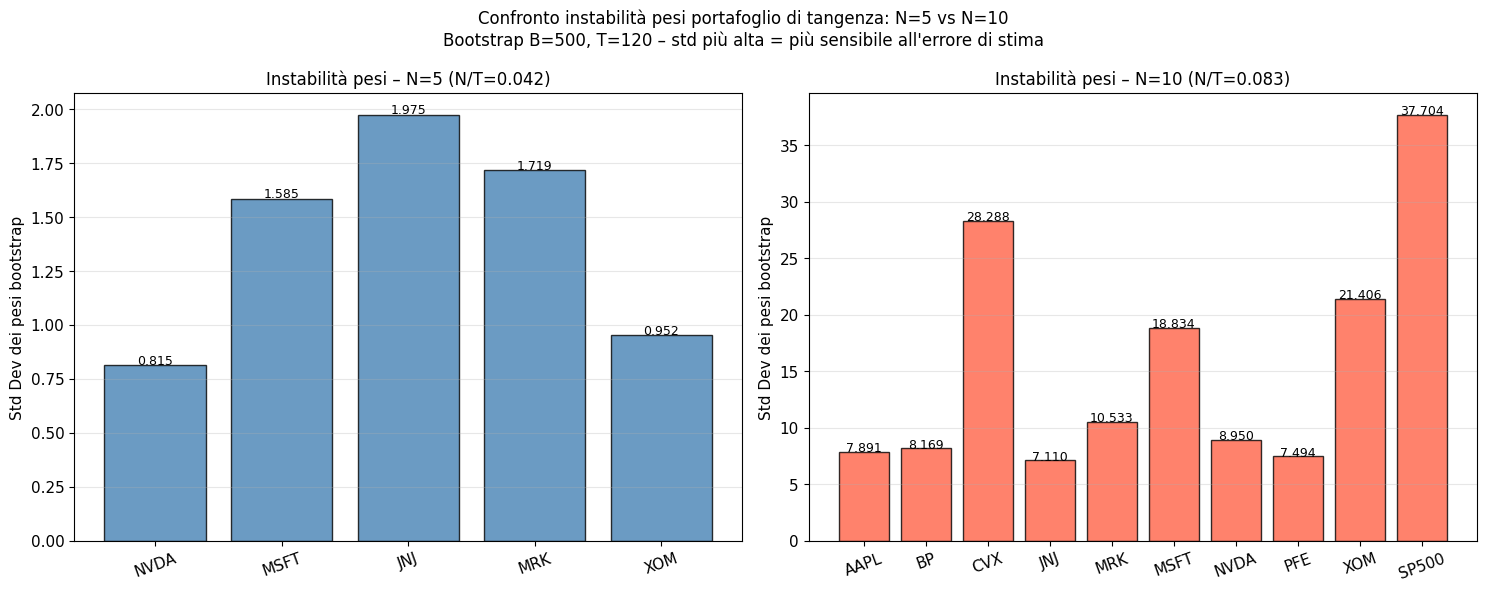

Salvato: bootstrap_stability_comparison_C5.png


In [24]:
# =============================================================================
# GRAFICO 5 – Confronto std dei pesi: N=5 vs N=10
# Mostra direttamente l'instabilità per asset al variare di N
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# N=5
ax = axes[0]
ax.bar(TICKERS_5, stds5, color='steelblue', edgecolor='black', alpha=0.8)
ax.set_title(f'Instabilità pesi – N=5 (N/T={5/T_BOOT:.3f})', fontsize=12)
ax.set_ylabel('Std Dev dei pesi bootstrap')
ax.tick_params(axis='x', rotation=20)
ax.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(stds5):
    ax.text(i, v + 0.003, f'{v:.3f}', ha='center', fontsize=9)

# N=10
ax = axes[1]
ax.bar(TICKERS_10, stds10, color='tomato', edgecolor='black', alpha=0.8)
ax.set_title(f'Instabilità pesi – N=10 (N/T={10/T_BOOT:.3f})', fontsize=12)
ax.set_ylabel('Std Dev dei pesi bootstrap')
ax.tick_params(axis='x', rotation=20)
ax.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(stds10):
    ax.text(i, v + 0.003, f'{v:.3f}', ha='center', fontsize=9)

fig.suptitle(
    'Confronto instabilità pesi portafoglio di tangenza: N=5 vs N=10\n'
    f'Bootstrap B={B}, T={T_BOOT} – std più alta = più sensibile all\'errore di stima',
    fontsize=12
)
fig.tight_layout()
fig.savefig('bootstrap_stability_comparison_C5.png', dpi=150)
plt.show()
print('Salvato: bootstrap_stability_comparison_C5.png')

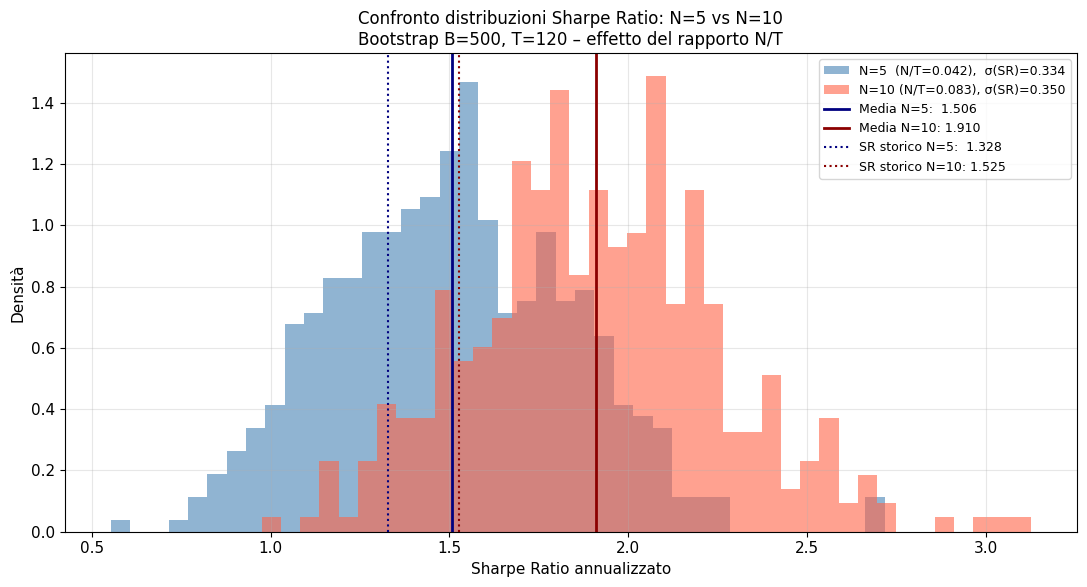

Salvato: bootstrap_sharpe_comparison_C5.png


In [25]:
# =============================================================================
# GRAFICO 6 – Confronto distribuzioni Sharpe Ratio: N=5 vs N=10
# Una distribuzione più larga = maggiore incertezza nella stima del SR
# =============================================================================
fig, ax = plt.subplots(figsize=(11, 6))

ax.hist(srs5[~np.isnan(srs5)],  bins=40, alpha=0.6, color='steelblue', density=True,
        label=f'N=5  (N/T={5/T_BOOT:.3f}),  σ(SR)={std_sr5:.3f}')
ax.hist(srs10[~np.isnan(srs10)], bins=40, alpha=0.6, color='tomato',    density=True,
        label=f'N=10 (N/T={10/T_BOOT:.3f}), σ(SR)={std_sr10:.3f}')

# Medie delle distribuzioni bootstrap
ax.axvline(mu_sr5,  color='navy',    lw=2.0, ls='-',
           label=f'Media N=5:  {mu_sr5:.3f}')
ax.axvline(mu_sr10, color='darkred', lw=2.0, ls='-',
           label=f'Media N=10: {mu_sr10:.3f}')

# SR storici (calcolati sull'intero campione)
ax.axvline(sr5_stor,  color='navy',    lw=1.5, ls=':',
           label=f'SR storico N=5:  {sr5_stor:.3f}')
ax.axvline(sr10_stor, color='darkred', lw=1.5, ls=':',
           label=f'SR storico N=10: {sr10_stor:.3f}')

ax.set_title('Confronto distribuzioni Sharpe Ratio: N=5 vs N=10\n'
             f'Bootstrap B={B}, T={T_BOOT} – effetto del rapporto N/T', fontsize=12)
ax.set_xlabel('Sharpe Ratio annualizzato'); ax.set_ylabel('Densità')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig('bootstrap_sharpe_comparison_C5.png', dpi=150)
plt.show()
print('Salvato: bootstrap_sharpe_comparison_C5.png')

---
## Blocco 7 – Riepilogo e commento (Punto 5)

### Risposta alle domande della traccia

**1. Come varia la stabilità dei pesi al crescere di N, mantenendo T fisso?**

All'aumentare di N (con T=120 fisso), i pesi del portafoglio di tangenza diventano progressivamente **meno stabili**. Questo si osserva sia nella larghezza dei boxplot (std più alta) sia nella dispersione dello Sharpe Ratio. Il fenomeno è noto in letteratura come *"error maximization"* (Michaud, 1989): l'ottimizzatore di Markowitz non è consapevole dell'incertezza statistica nelle stime di $\hat{\mu}$ e $\hat{\Sigma}$, e quindi tratta come veri i valori stimati, amplificando gli errori di campionamento.

**2. Qual è il ruolo del rapporto N/T?**

Il rapporto $N/T$ è il parametro chiave della stabilità:

| Caso | N | T | N/T | Parametri $\Sigma$ | Stabilità |
|------|---|---|-----|--------------------|-----------|
| 1 | 5  | 120 | 0.042 | 15  | Alta |
| 2 | 10 | 120 | 0.083 | 55  | Media |
| (ipotetico) | 60 | 120 | 0.500 | 1830 | Bassa |
| (limite) | 120 | 120 | 1.000 | — | Singolare |

Per $N = T$, la matrice $\hat{\Sigma}$ ha rango al più $T-1 < N$ e non è invertibile. Per $N > T$ il problema è mathematicamente ill-posed e la soluzione analitica non esiste.

**Implicazioni pratiche:**
- Con N/T piccolo (< 0.1): la frontiera efficiente stimata è una buona approssimazione di quella reale
- Con N/T grande: i pesi ottimali stimati sono molto lontani da quelli veri → i portafogli "ottimali" possono avere performance deludenti out-of-sample
- **Soluzione**: ridurre N, aumentare T, usare stimatori di covarianza più robusti (shrinkage, modelli a fattori come il SIM della Parte B), oppure imporre vincoli ai pesi

In [26]:
# =============================================================================
# RIEPILOGO NUMERICO FINALE (Punto 5)
# =============================================================================
print('=' * 65)
print('RIEPILOGO – Stabilità portafoglio di tangenza (Bootstrap i.i.d.)')
print('=' * 65)

summary = pd.DataFrame({
    'N': [5, 10],
    'T': [T_BOOT, T_BOOT],
    'N/T': [5/T_BOOT, 10/T_BOOT],
    'Param. Sigma': [5*6//2, 10*11//2],
    'SR storico': [round(sr5_stor, 4), round(sr10_stor, 4)],
    'Media SR boot.': [round(mu_sr5, 4), round(mu_sr10, 4)],
    'Std SR boot.': [round(std_sr5, 4), round(std_sr10, 4)],
    'Std media pesi': [round(stds5.mean(), 4), round(stds10.mean(), 4)],
}).set_index('N')

display(summary)

print()
print('Conclusione:')
print(f'  Passando da N=5 (N/T={5/T_BOOT:.3f}) a N=10 (N/T={10/T_BOOT:.3f}):')
print(f'  - Std media dei pesi: {stds5.mean():.4f} → {stds10.mean():.4f} '
      f'(+{(stds10.mean()/stds5.mean()-1)*100:.0f}%)')
print(f'  - Std dello Sharpe:   {std_sr5:.4f} → {std_sr10:.4f} '
      f'(+{(std_sr10/std_sr5-1)*100:.0f}%)')
print()
print('  L\'errore di stima aumenta con N/T: con T fisso, un numero maggiore')
print('  di asset rende i pesi ottimali più instabili e l\'out-of-sample')
print('  performance del portafoglio di tangenza più imprevedibile.')

RIEPILOGO – Stabilità portafoglio di tangenza (Bootstrap i.i.d.)


,T,N/T,Param. Sigma,SR storico,Media SR boot.,Std SR boot.,Std media pesi
N,,,,,,,
5,120,0.041667,15,1.3278,1.5065,0.3336,1.4093
10,120,0.083333,55,1.5255,1.9105,0.3497,15.6381



Conclusione:
  Passando da N=5 (N/T=0.042) a N=10 (N/T=0.083):
  - Std media dei pesi: 1.4093 → 15.6381 (+1010%)
  - Std dello Sharpe:   0.3336 → 0.3497 (+5%)

  L'errore di stima aumenta con N/T: con T fisso, un numero maggiore
  di asset rende i pesi ottimali più instabili e l'out-of-sample
  performance del portafoglio di tangenza più imprevedibile.
